# PRISM Clinical Confidence Layer

## Unsupervised Clustering of High-Benefit Patient Archetypes

This notebook implements a Clinical Confidence Layer that answers:

> **Does this patient's clinical profile resemble previously observed high-benefit patients?**

It consumes predicted treatment effects from the DR-learner notebook, identifies high-benefit
patient archetypes via Gaussian Mixture Models, and scores new patients on how well they
resemble those historical archetypes.

**Key distinction:** This is a resemblance/novelty-detection score, not a prediction accuracy score.

---
## Setup and Imports
---

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors, KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

try:
    from sklearn.cluster import HDBSCAN
except ImportError:
    from hdbscan import HDBSCAN

# Path setup for _prism_model_utils
for candidate in [Path.cwd(), Path.cwd() / 'Code']:
    if (candidate / '_prism_model_utils.py').exists():
        sys.path.insert(0, str(candidate))
        break

from _prism_model_utils import (
    project_root,
    ensure_output_folder,
    split_train_test,
    ntile_desc,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = project_root()
SEED = 123
np.random.seed(SEED)

print('Project root:', PROJECT_ROOT)

Project root: /home/sagemaker-user/prism_repo


---
## Step 1 – Load DR-Learner Outputs

Load the scored outputs from the Doubly Robust notebook. Reconstruct the train/test split
using the same deterministic parameters (seed=123, fraction=0.70, stratified).
---

In [2]:
# --- Configuration ---
DR_OUTPUT_DIR = PROJECT_ROOT / 'Outputs' / 'Doubly-Robust' / 'Python'
OUTPUT_DIR = ensure_output_folder(PROJECT_ROOT / 'Outputs' / 'Clinical-Confidence' / 'Python')

TRAIN_FRACTION = 0.70
HIGH_BENEFIT_PERCENTILE = 0.20  # Top 20%
N_SHAP_FEATURES = 12  # Number of SHAP features to retain for clustering
N_BOOTSTRAP = 100  # Bootstrap iterations for stability
KNN_K = 10  # k for nearest-neighbor similarity

# --- Load DR-learner scored full population ---
scored_full = pd.read_csv(DR_OUTPUT_DIR / 'doubly_robust_scored_output.csv')
scored_test = pd.read_csv(DR_OUTPUT_DIR / 'doubly_robust_scored_test_output.csv')
shap_importance = pd.read_csv(DR_OUTPUT_DIR / 'doubly_robust_global_benefit_shap_importance.csv')

print(f'Full scored population: {len(scored_full)} members')
print(f'Test scored population: {len(scored_test)} members')
print(f'SHAP features available: {len(shap_importance)}')

# --- Reconstruct train/test split (same deterministic split as DR notebook) ---
train_df, test_df = split_train_test(
    scored_full,
    train_fraction=TRAIN_FRACTION,
    seed=SEED,
    stratify_columns=['intervention_flag', 'outcome_ed_90d'],
)

print(f'\nReconstructed split:')
print(f'  Training: {len(train_df)} members')
print(f'  Test: {len(test_df)} members')
print(f'\nBenefit score range (train): [{train_df["benefit_score"].min():.4f}, {train_df["benefit_score"].max():.4f}]')
print(f'Benefit score range (test): [{test_df["benefit_score"].min():.4f}, {test_df["benefit_score"].max():.4f}]')

Full scored population: 1000 members
Test scored population: 300 members
SHAP features available: 77

Reconstructed split:
  Training: 700 members
  Test: 300 members

Benefit score range (train): [-0.0076, 0.0950]
Benefit score range (test): [0.0107, 0.0798]


---
## Step 2 – Construct High-Benefit Reference Population

Select the top 20% of training members by predicted benefit score.
These ~140 patients form the historical reference for the confidence layer.
---

In [3]:
# --- Select top 20% high-benefit training patients ---
benefit_threshold_train = train_df['benefit_score'].quantile(1 - HIGH_BENEFIT_PERCENTILE)
high_benefit_train = train_df[train_df['benefit_score'] >= benefit_threshold_train].copy()

# --- Similarly for test ---
benefit_threshold_test = test_df['benefit_score'].quantile(1 - HIGH_BENEFIT_PERCENTILE)
high_benefit_test = test_df[test_df['benefit_score'] >= benefit_threshold_test].copy()

print(f'High-benefit training population: {len(high_benefit_train)} members')
print(f'  Benefit score threshold: >= {benefit_threshold_train:.4f}')
print(f'  Mean benefit score: {high_benefit_train["benefit_score"].mean():.4f}')
print(f'\nHigh-benefit test population: {len(high_benefit_test)} members')
print(f'  Benefit score threshold: >= {benefit_threshold_test:.4f}')
print(f'  Mean benefit score: {high_benefit_test["benefit_score"].mean():.4f}')

High-benefit training population: 140 members
  Benefit score threshold: >= 0.0568
  Mean benefit score: 0.0671

High-benefit test population: 60 members
  Benefit score threshold: >= 0.0555
  Mean benefit score: 0.0639


---
## Step 3 – Feature Selection for Clustering (SHAP-Based)

Select the top 12 features by mean absolute SHAP value from the DR-learner model.
This ensures archetypes are defined by features that drive treatment benefit predictions.
---

In [4]:
# --- Select top SHAP features ---
top_shap_features = shap_importance.nlargest(N_SHAP_FEATURES, 'mean_abs_benefit_shap')['feature'].tolist()

# Filter to features actually present in the scored data (some may be one-hot encoded names)
available_features = [f for f in top_shap_features if f in high_benefit_train.columns]

# If some SHAP features are one-hot encoded and not in raw columns, fall back to more
if len(available_features) < N_SHAP_FEATURES:
    # Add more from the list
    for f in shap_importance['feature'].tolist():
        if f in high_benefit_train.columns and f not in available_features:
            available_features.append(f)
        if len(available_features) >= N_SHAP_FEATURES:
            break

CLUSTER_FEATURES = available_features[:N_SHAP_FEATURES]
print(f'Selected {len(CLUSTER_FEATURES)} features for clustering:')
for i, feat in enumerate(CLUSTER_FEATURES, 1):
    shap_val = shap_importance.loc[shap_importance['feature'] == feat, 'mean_abs_benefit_shap']
    shap_str = f'{shap_val.values[0]:.4f}' if len(shap_val) > 0 else 'N/A'
    print(f'  {i:2d}. {feat} (mean |SHAP| = {shap_str})')

# --- Extract feature matrices ---
X_train_raw = high_benefit_train[CLUSTER_FEATURES].copy()
X_test_raw = high_benefit_test[CLUSTER_FEATURES].copy()

# Ensure numeric (coerce any categorical stragglers)
X_train_raw = X_train_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_raw = X_test_raw.apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Standardize: fit ONLY on training high-benefit patients ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)  # No data leakage

print(f'\nScaled training matrix shape: {X_train_scaled.shape}')
print(f'Scaled test matrix shape: {X_test_scaled.shape}')

Selected 12 features for clustering:
   1. percolator_clinical_score (mean |SHAP| = 0.0040)
   2. age (mean |SHAP| = 0.0040)
   3. current_risk_score (mean |SHAP| = 0.0030)
   4. percolator_utilization_score (mean |SHAP| = 0.0022)
   5. med_adherence_pdc (mean |SHAP| = 0.0021)
   6. percolator_sdoh_score (mean |SHAP| = 0.0017)
   7. pcp_visits_last_6m (mean |SHAP| = 0.0015)
   8. ed_visits_last_6m (mean |SHAP| = 0.0015)
   9. rx_count_last_6m (mean |SHAP| = 0.0013)
  10. total_cost_last_6m (mean |SHAP| = 0.0011)
  11. anxiety_flag (mean |SHAP| = 0.0010)
  12. copd_flag (mean |SHAP| = 0.0006)

Scaled training matrix shape: (140, 12)
Scaled test matrix shape: (60, 12)


---
## Step 4 – Discover High-Benefit Patient Archetypes

**Primary method:** Gaussian Mixture Model (GMM) with BIC-based component selection.
**Stability checks:** K-Means and Agglomerative Clustering.
**Diagnostic layer:** HDBSCAN for noise/outlier detection.
---

GMM MODEL SELECTION
BIC-optimal number of clusters: 6
BIC scores: {2: 2964.6, 3: 5045.3, 4: 3034.9, 5: 2688.7, 6: 2045.8, 7: 3139.5, 8: 2808.2}


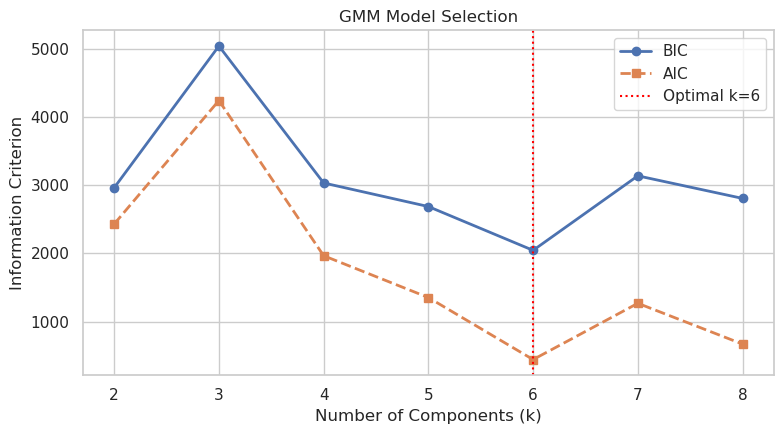



K-MEANS MODEL SELECTION
Highest silhouette at k = 6


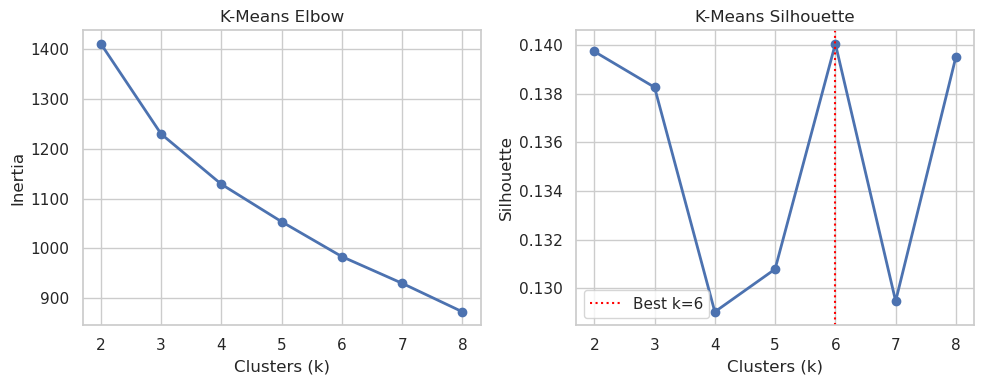



CLUSTER SUMMARIES

GMM
{0: 34, 1: 61, 2: 7, 3: 6, 4: 10, 5: 22}

K-Means
Inertia: 983.40
{0: 42, 1: 10, 2: 18, 3: 21, 4: 18, 5: 31}

Agglomerative
{0: 23, 1: 25, 2: 14, 3: 25, 4: 27, 5: 26}

HDBSCAN
Clusters found: 4
Noise points: 61 (43.6%)
{-1: 61, 0: 7, 1: 50, 2: 16, 3: 6}


SILHOUETTE SCORES
GMM:            0.093
K-Means:        0.140
Agglomerative:  0.114
HDBSCAN:        0.110


CROSS-METHOD AGREEMENT (ARI)
GMM vs K-Means:        0.345
GMM vs Agglomerative:  0.454
K-Means vs Agglomerative: 0.433


In [5]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

# =============================================================================
# GMM MODEL SELECTION (PRIMARY ANALYSIS)
# =============================================================================

k_range = range(2, 9)
bic_scores = []
aic_scores = []

for k in k_range:

    gmm_candidate = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=SEED,
        n_init=10,
    )

    gmm_candidate.fit(X_train_scaled)

    bic_scores.append(gmm_candidate.bic(X_train_scaled))
    aic_scores.append(gmm_candidate.aic(X_train_scaled))

optimal_k = list(k_range)[np.argmin(bic_scores)]

print("=" * 70)
print("GMM MODEL SELECTION")
print("=" * 70)
print(f"BIC-optimal number of clusters: {optimal_k}")
print(f"BIC scores: {dict(zip(k_range, np.round(bic_scores,1)))}")

# Plot
fig, ax = plt.subplots(figsize=(8,4.5))

ax.plot(k_range, bic_scores, "o-", linewidth=2, label="BIC")
ax.plot(k_range, aic_scores, "s--", linewidth=2, label="AIC")

ax.axvline(
    optimal_k,
    color="red",
    linestyle=":",
    label=f"Optimal k={optimal_k}",
)

ax.set_xlabel("Number of Components (k)")
ax.set_ylabel("Information Criterion")
ax.set_title("GMM Model Selection")
ax.legend()

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "gmm_bic_aic_selection.png",
    dpi=150,
)

plt.show()

# =============================================================================
# K-MEANS MODEL SELECTION (DIAGNOSTIC ONLY)
# =============================================================================

inertia = []
kmeans_silhouette = []

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=20,
    )

    labels = km.fit_predict(X_train_scaled)

    inertia.append(km.inertia_)
    kmeans_silhouette.append(
        silhouette_score(X_train_scaled, labels)
    )

best_kmeans_k = list(k_range)[np.argmax(kmeans_silhouette)]

print("\n")
print("=" * 70)
print("K-MEANS MODEL SELECTION")
print("=" * 70)
print(f"Highest silhouette at k = {best_kmeans_k}")

fig, ax = plt.subplots(1,2,figsize=(10,4))

# Elbow
ax[0].plot(k_range, inertia, "o-", linewidth=2)
ax[0].set_xlabel("Clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("K-Means Elbow")

# Silhouette
ax[1].plot(k_range, kmeans_silhouette, "o-", linewidth=2)
ax[1].axvline(
    best_kmeans_k,
    color="red",
    linestyle=":",
    label=f"Best k={best_kmeans_k}",
)
ax[1].legend()
ax[1].set_xlabel("Clusters (k)")
ax[1].set_ylabel("Silhouette")
ax[1].set_title("K-Means Silhouette")

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL CLUSTERING MODELS
# (ALL USE GMM-SELECTED NUMBER OF CLUSTERS)
# =============================================================================

# ----- Gaussian Mixture -----

gmm = GaussianMixture(
    n_components=optimal_k,
    covariance_type="full",
    random_state=SEED,
    n_init=10,
)

gmm_labels = gmm.fit_predict(X_train_scaled)

# ----- K-Means -----

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=SEED,
    n_init=20,
)

kmeans_labels = kmeans.fit_predict(X_train_scaled)

# ----- Agglomerative -----

agg = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward",
)

agg_labels = agg.fit_predict(X_train_scaled)

# ----- HDBSCAN -----

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=3,
)

hdbscan_labels = hdbscan_model.fit_predict(X_train_scaled)

# =============================================================================
# CLUSTER SUMMARIES
# =============================================================================

print("\n")
print("=" * 70)
print("CLUSTER SUMMARIES")
print("=" * 70)

print("\nGMM")
print(dict(zip(*np.unique(gmm_labels, return_counts=True))))

print("\nK-Means")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(dict(zip(*np.unique(kmeans_labels, return_counts=True))))

print("\nAgglomerative")
print(dict(zip(*np.unique(agg_labels, return_counts=True))))

print("\nHDBSCAN")

noise = np.sum(hdbscan_labels == -1)

print(f"Clusters found: {len(set(hdbscan_labels)-{-1})}")
print(f"Noise points: {noise} ({noise/len(hdbscan_labels):.1%})")
print(dict(zip(*np.unique(hdbscan_labels, return_counts=True))))

# =============================================================================
# SILHOUETTE SCORES
# =============================================================================

sil_gmm = silhouette_score(X_train_scaled, gmm_labels)
sil_kmeans = silhouette_score(X_train_scaled, kmeans_labels)
sil_agg = silhouette_score(X_train_scaled, agg_labels)

mask = hdbscan_labels != -1

if len(np.unique(hdbscan_labels[mask])) >= 2:
    sil_hdbscan = silhouette_score(
        X_train_scaled[mask],
        hdbscan_labels[mask],
    )
else:
    sil_hdbscan = np.nan

print("\n")
print("=" * 70)
print("SILHOUETTE SCORES")
print("=" * 70)

print(f"GMM:            {sil_gmm:.3f}")
print(f"K-Means:        {sil_kmeans:.3f}")
print(f"Agglomerative:  {sil_agg:.3f}")

if np.isnan(sil_hdbscan):
    print("HDBSCAN:        Not available")
else:
    print(f"HDBSCAN:        {sil_hdbscan:.3f}")

# =============================================================================
# CROSS-METHOD AGREEMENT
# =============================================================================

ari_gmm_kmeans = adjusted_rand_score(
    gmm_labels,
    kmeans_labels,
)

ari_gmm_agg = adjusted_rand_score(
    gmm_labels,
    agg_labels,
)

ari_kmeans_agg = adjusted_rand_score(
    kmeans_labels,
    agg_labels,
)

print("\n")
print("=" * 70)
print("CROSS-METHOD AGREEMENT (ARI)")
print("=" * 70)

print(f"GMM vs K-Means:        {ari_gmm_kmeans:.3f}")
print(f"GMM vs Agglomerative:  {ari_gmm_agg:.3f}")
print(f"K-Means vs Agglomerative: {ari_kmeans_agg:.3f}")

### Archetype Profiles

Summarize each discovered archetype by clinical characteristics.

In [6]:
# --- Build archetype profiles ---
high_benefit_train_labeled = high_benefit_train.copy()
high_benefit_train_labeled['archetype'] = gmm_labels

# Summary by archetype
profile_features = CLUSTER_FEATURES + ['benefit_score']
if 'current_risk_score' in high_benefit_train.columns and 'current_risk_score' not in profile_features:
    profile_features.append('current_risk_score')

archetype_profiles = (
    high_benefit_train_labeled
    .groupby('archetype')[profile_features]
    .agg(['mean', 'std', 'count'])
)

# Simplified summary table
archetype_summary_rows = []
for cluster_id in sorted(high_benefit_train_labeled['archetype'].unique()):
    cluster_data = high_benefit_train_labeled[high_benefit_train_labeled['archetype'] == cluster_id]
    row = {
        'archetype': cluster_id,
        'n_patients': len(cluster_data),
        'avg_benefit_score': cluster_data['benefit_score'].mean(),
    }
    for feat in CLUSTER_FEATURES:
        if feat in cluster_data.columns:
            row[f'avg_{feat}'] = cluster_data[feat].mean()
    archetype_summary_rows.append(row)

archetype_summary = pd.DataFrame(archetype_summary_rows)
archetype_summary.to_csv(OUTPUT_DIR / 'archetype_summary.csv', index=False)

print('Archetype Summary:')
display(archetype_summary)

Archetype Summary:


,archetype,n_patients,avg_benefit_score,avg_percolator_clinical_score,avg_age,avg_current_risk_score,avg_percolator_utilization_score,avg_med_adherence_pdc,avg_percolator_sdoh_score,avg_pcp_visits_last_6m,avg_ed_visits_last_6m,avg_rx_count_last_6m,avg_total_cost_last_6m,avg_anxiety_flag,avg_copd_flag
0,0,34,0.068872,68.750000,65.588235,55.232353,52.338235,0.797912,34.626471,3.735294,1.294118,9.676471,4747.763824,0.000000,1.000000
1,1,61,0.066369,57.278689,58.262295,50.826230,51.327869,0.748344,32.434426,2.704918,1.344262,8.163934,4763.450656,0.000000,0.000000
2,2,7,0.066838,71.571429,72.714286,61.614286,58.428571,0.677429,47.814286,5.428571,1.571429,12.857143,6600.695714,0.428571,0.428571
3,3,6,0.060685,31.683333,37.500000,36.916667,40.750000,0.709000,24.050000,2.833333,0.500000,3.333333,4216.795000,1.000000,0.166667
4,4,10,0.072138,63.460000,55.900000,69.130000,88.580000,0.772900,36.040000,2.600000,3.100000,9.600000,9335.225000,0.300000,0.400000
5,5,22,0.066105,64.545455,61.954545,52.259091,48.486364,0.771136,40.640909,3.318182,1.000000,9.681818,4633.965909,1.000000,0.500000


---
## Step 5 – Validate Cluster Stability

Stability is a gating step. If archetypes aren't reproducible at n~140, they shouldn't
be presented as clinical phenotypes.
---

In [7]:
# --- Internal validation metrics ---
sil_score = silhouette_score(X_train_scaled, gmm_labels)
db_score = davies_bouldin_score(X_train_scaled, gmm_labels)
ch_score = calinski_harabasz_score(X_train_scaled, gmm_labels)

print('Internal Cluster Validation (GMM primary):')
print(f'  Silhouette Score: {sil_score:.3f} (higher is better, range [-1, 1])')
print(f'  Davies-Bouldin Index: {db_score:.3f} (lower is better)')
print(f'  Calinski-Harabasz Index: {ch_score:.1f} (higher is better)')

# --- Bootstrap resampling for stability ---
rng = np.random.default_rng(SEED)
bootstrap_ari_scores = []

for i in range(N_BOOTSTRAP):
    indices = rng.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled[indices]
    gmm_boot = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=SEED + i, n_init=5)
    gmm_boot.fit(X_boot)
    boot_labels = gmm_boot.predict(X_train_scaled)
    ari = adjusted_rand_score(gmm_labels, boot_labels)
    bootstrap_ari_scores.append(ari)

bootstrap_ari = np.array(bootstrap_ari_scores)
print(f'\nBootstrap Stability ({N_BOOTSTRAP} iterations):')
print(f'  Mean ARI: {bootstrap_ari.mean():.3f}')
print(f'  Std ARI: {bootstrap_ari.std():.3f}')
print(f'  Median ARI: {np.median(bootstrap_ari):.3f}')

stability_assessment = 'STRONG' if bootstrap_ari.mean() > 0.7 else ('MODERATE' if bootstrap_ari.mean() > 0.5 else 'WEAK')
print(f'  Stability assessment: {stability_assessment}')

stability_summary = pd.DataFrame([{
    'n_components': optimal_k, 'silhouette_score': sil_score,
    'davies_bouldin_index': db_score, 'calinski_harabasz_index': ch_score,
    'bootstrap_mean_ari': bootstrap_ari.mean(), 'bootstrap_std_ari': bootstrap_ari.std(),
    'ari_gmm_vs_kmeans': ari_gmm_kmeans, 'ari_gmm_vs_agglomerative': ari_gmm_agg,
    'stability_assessment': stability_assessment,
}])
stability_summary.to_csv(OUTPUT_DIR / 'cluster_stability_summary.csv', index=False)
display(stability_summary)

Internal Cluster Validation (GMM primary):
  Silhouette Score: 0.093 (higher is better, range [-1, 1])
  Davies-Bouldin Index: 1.965 (lower is better)
  Calinski-Harabasz Index: 12.6 (higher is better)



Bootstrap Stability (100 iterations):
  Mean ARI: 0.361
  Std ARI: 0.161
  Median ARI: 0.318
  Stability assessment: WEAK


,n_components,silhouette_score,davies_bouldin_index,calinski_harabasz_index,bootstrap_mean_ari,bootstrap_std_ari,ari_gmm_vs_kmeans,ari_gmm_vs_agglomerative,stability_assessment
0,6,0.092993,1.964852,12.620889,0.360794,0.160722,0.344925,0.453976,WEAK


---
## Steps 6 & 7 – Score Test Patients Against Historical Clusters
---

In [8]:
# --- 1. GMM Posterior Probabilities ---
test_gmm_proba = gmm.predict_proba(X_test_scaled)
test_gmm_max_posterior = test_gmm_proba.max(axis=1)
test_gmm_labels = gmm.predict(X_test_scaled)

print('GMM Posterior (test high-benefit):')
print(f'  Mean max posterior: {test_gmm_max_posterior.mean():.3f}')
print(f'  Patients with posterior > 0.8: {(test_gmm_max_posterior > 0.8).sum()}')

# --- 2. k-NN Distance ---
knn = NearestNeighbors(n_neighbors=KNN_K, metric='euclidean')
knn.fit(X_train_scaled)
distances, _ = knn.kneighbors(X_test_scaled)
mean_knn_distance = distances.mean(axis=1)
knn_similarity = 1.0 / (1.0 + mean_knn_distance)

print(f'\nk-NN Similarity (k={KNN_K}): mean={knn_similarity.mean():.3f}')

# --- 3. Local Density (KDE) ---
n_train = len(X_train_scaled)
d_features = X_train_scaled.shape[1]
bandwidth = n_train ** (-1.0 / (d_features + 4))
kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
kde.fit(X_train_scaled)

train_log_density = kde.score_samples(X_train_scaled)
test_log_density = kde.score_samples(X_test_scaled)
density_min, density_max = train_log_density.min(), train_log_density.max()
density_range = max(density_max - density_min, 1e-10)
test_density_normalized = np.clip((test_log_density - density_min) / density_range, 0, 1)

print(f'  Local Density: mean={test_density_normalized.mean():.3f}')

# --- 4. HDBSCAN Diagnostic ---
try:
    from hdbscan import approximate_predict
    test_hdbscan_labels, _ = approximate_predict(hdbscan_model, X_test_scaled)
except (ImportError, AttributeError, Exception):
    combined_scaled = np.vstack([X_train_scaled, X_test_scaled])
    hdb_comb = HDBSCAN(min_cluster_size=15, min_samples=5)
    comb_labels = hdb_comb.fit_predict(combined_scaled)
    test_hdbscan_labels = comb_labels[len(X_train_scaled):]

test_hdbscan_noise = (test_hdbscan_labels == -1)
print(f'  HDBSCAN noise: {test_hdbscan_noise.sum()} ({test_hdbscan_noise.mean():.1%})')

GMM Posterior (test high-benefit):
  Mean max posterior: 1.000
  Patients with posterior > 0.8: 60

k-NN Similarity (k=10): mean=0.258
  Local Density: mean=0.000
  HDBSCAN noise: 60 (100.0%)


---
## Step 8 – Construct Clinical Confidence Score
---

In [9]:
# Equal weighting: GMM posterior + kNN similarity + local density
confidence_score = (test_gmm_max_posterior + knn_similarity + test_density_normalized) / 3.0

# Min-max normalize to [0, 1]
cs_min, cs_max = confidence_score.min(), confidence_score.max()
cs_range = max(cs_max - cs_min, 1e-10)
confidence_score_normalized = (confidence_score - cs_min) / cs_range

print('Clinical Confidence Score (test high-benefit):')
print(f'  Mean: {confidence_score_normalized.mean():.3f}')
print(f'  Std: {confidence_score_normalized.std():.3f}')
print(f'  Range: [{confidence_score_normalized.min():.3f}, {confidence_score_normalized.max():.3f}]')

Clinical Confidence Score (test high-benefit):
  Mean: 0.509
  Std: 0.238
  Range: [0.000, 1.000]


---
## Step 9 – Assign Confidence Categories
---

In [10]:
tercile_low = np.percentile(confidence_score_normalized, 33.33)
tercile_high = np.percentile(confidence_score_normalized, 66.67)

confidence_tiers = np.where(
    confidence_score_normalized >= tercile_high, 'High',
    np.where(confidence_score_normalized >= tercile_low, 'Medium', 'Low')
)

scored_confidence = high_benefit_test.reset_index(drop=True).copy()
scored_confidence['gmm_archetype'] = test_gmm_labels
scored_confidence['gmm_max_posterior'] = test_gmm_max_posterior
scored_confidence['knn_similarity'] = knn_similarity
scored_confidence['density_normalized'] = test_density_normalized
scored_confidence['clinical_confidence_score'] = confidence_score_normalized
scored_confidence['confidence_tier'] = confidence_tiers
scored_confidence['hdbscan_noise_flag'] = test_hdbscan_noise.astype(int)

tier_summary = scored_confidence.groupby('confidence_tier').agg(
    n=('clinical_confidence_score', 'count'),
    avg_confidence=('clinical_confidence_score', 'mean'),
    avg_benefit=('benefit_score', 'mean'),
    avg_posterior=('gmm_max_posterior', 'mean'),
    avg_knn_sim=('knn_similarity', 'mean'),
    avg_density=('density_normalized', 'mean'),
).reindex(['High', 'Medium', 'Low']).reset_index()

print('Confidence Tier Summary:')
display(tier_summary)
tier_summary.to_csv(OUTPUT_DIR / 'confidence_tier_summary.csv', index=False)
scored_confidence.to_csv(OUTPUT_DIR / 'scored_confidence_test_patients.csv', index=False)

Confidence Tier Summary:


,confidence_tier,n,avg_confidence,avg_benefit,avg_posterior,avg_knn_sim,avg_density
0,High,20,0.778858,0.066903,1.0,0.292411,0.0
1,Medium,20,0.499549,0.063055,1.0,0.256812,0.0
2,Low,20,0.247479,0.061817,1.0,0.224685,0.0


---
## Step 9a – Visualization
---

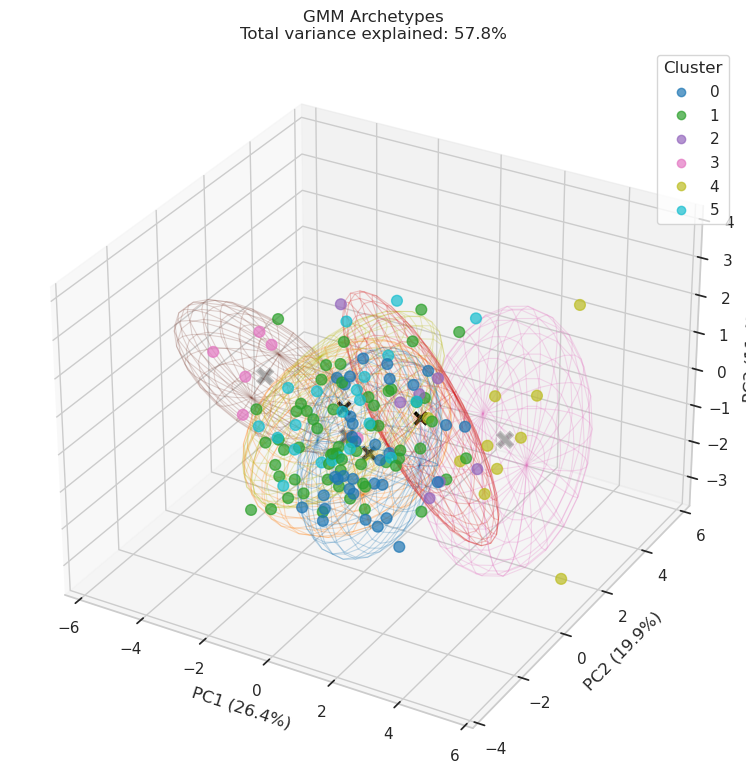

In [15]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.linalg import eigh

# Project GMM means into PCA space
gmm_means_pca = pca.transform(gmm.means_)

# Project covariance matrices into PCA space
components = pca.components_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot training points
sc = ax.scatter(
    train_coords[:, 0],
    train_coords[:, 1],
    train_coords[:, 2],
    c=gmm_labels,
    cmap="tab10",
    s=60,
    alpha=0.7,
)

# Draw cluster centroids
ax.scatter(
    gmm_means_pca[:, 0],
    gmm_means_pca[:, 1],
    gmm_means_pca[:, 2],
    c="black",
    marker="X",
    s=180,
    linewidth=2,
    edgecolors="white",
    label="Centroid",
)

# Draw covariance ellipsoids
u = np.linspace(0, 2 * np.pi, 25)
v = np.linspace(0, np.pi, 15)

for i in range(optimal_k):

    # Project covariance into PCA space
    cov_pca = components @ gmm.covariances_[i] @ components.T

    # Eigen-decomposition
    vals, vecs = eigh(cov_pca)

    # Sort largest first
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    # 95% confidence ellipsoid
    radii = 2 * np.sqrt(vals)

    x = radii[0] * np.outer(np.cos(u), np.sin(v))
    y = radii[1] * np.outer(np.sin(u), np.sin(v))
    z = radii[2] * np.outer(np.ones_like(u), np.cos(v))

    xyz = np.stack([x, y, z], axis=-1)

    xyz = xyz @ vecs.T

    xyz[:, :, 0] += gmm_means_pca[i, 0]
    xyz[:, :, 1] += gmm_means_pca[i, 1]
    xyz[:, :, 2] += gmm_means_pca[i, 2]

    ax.plot_wireframe(
        xyz[:, :, 0],
        xyz[:, :, 1],
        xyz[:, :, 2],
        color=sc.cmap(i / optimal_k),
        alpha=0.25,
        linewidth=0.8,
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")

ax.set_title(
    f"GMM Archetypes\nTotal variance explained: {pca.explained_variance_ratio_.sum():.1%}"
)

ax.legend(*sc.legend_elements(), title="Cluster", loc="upper right")

plt.tight_layout()
plt.show()

---
## Step 10 (Appendix) – Ground-Truth Sanity Check
---

In [12]:
if 'true_benefit' in scored_confidence.columns:
    truth_by_tier = scored_confidence.groupby('confidence_tier').agg(
        n=('true_benefit', 'count'),
        avg_true_benefit=('true_benefit', 'mean'),
        avg_predicted_benefit=('benefit_score', 'mean'),
    ).reindex(['High', 'Medium', 'Low']).reset_index()

    vals = truth_by_tier['avg_true_benefit'].tolist()
    is_monotonic = all(vals[i] >= vals[i+1] for i in range(len(vals)-1))

    print('Ground-Truth Validation by Tier:')
    display(truth_by_tier)
    print(f'Monotonicity (High >= Med >= Low): {is_monotonic}')

    corr = scored_confidence['clinical_confidence_score'].corr(scored_confidence['true_benefit'])
    print(f'Pearson corr (confidence vs true benefit): {corr:.3f}')
    truth_by_tier.to_csv(OUTPUT_DIR / 'ground_truth_validation_by_tier.csv', index=False)
else:
    print('No true_benefit column — skipping (expected for real data).')

No true_benefit column — skipping (expected for real data).


---
## Output Index
---

In [13]:
output_files = sorted(OUTPUT_DIR.iterdir())
print(f'Outputs saved to: {OUTPUT_DIR}\n')
for f in output_files:
    print(f'  {f.name}')
print(f'\n--- Summary ---')
print(f'Training reference: {len(high_benefit_train)} high-benefit patients')
print(f'Test scored: {len(high_benefit_test)} high-benefit patients')
print(f'Features: {len(CLUSTER_FEATURES)} (SHAP-selected)')
print(f'GMM components: {optimal_k} (BIC-optimal)')
print(f'Stability: {stability_assessment}')

Outputs saved to: /home/sagemaker-user/prism_repo/Outputs/Clinical-Confidence/Python

  archetype_summary.csv
  cluster_stability_summary.csv
  confidence_tier_summary.csv
  gmm_bic_aic_selection.png
  pca_archetypes_confidence_tiers.png
  scored_confidence_test_patients.csv

--- Summary ---
Training reference: 140 high-benefit patients
Test scored: 60 high-benefit patients
Features: 12 (SHAP-selected)
GMM components: 6 (BIC-optimal)
Stability: WEAK
